# 뉴스 데이터 자연어 처리 모델 호환 스터디 자료 수정본

- 담당자: 최지용
- 기본 모델: CNN / TextCNN
- 호환 모델: `CNN`, `RNN`, `LSTM`, `GRU`, `EMBED`
- 주제: 뉴스 제목과 요약을 활용한 카테고리 분류
- 목적: 모델 이름만 바꿔도 동일한 전처리, 학습, 평가, 추론 코드가 작동하도록 구성

## 이번 수정의 핵심

1. `.py` 파일에서도 `display()` 에러가 나지 않도록 안전 처리했다.
2. `MODEL_NAME`만 바꾸면 CNN/RNN/LSTM/GRU/Embedding Baseline으로 교체된다.
3. 모델 저장 파일명을 모델별로 다르게 만들어, CNN 가중치를 LSTM에 불러오는 호환 에러를 막았다.
4. 학습, 평가, 추론 함수는 모든 모델이 공통으로 사용한다.
5. `DEVICE` 처리를 넣어 CPU/GPU 어디서든 같은 코드가 돌아가게 했다.

## 전체 실행 흐름

```text
CSV 로드
↓
title + summary 결합
↓
텍스트 정제
↓
토큰화
↓
Vocabulary 생성
↓
Padding
↓
Label Encoding
↓
TensorDataset / DataLoader
↓
MODEL_NAME에 따라 모델 생성
↓
학습
↓
Validation 평가 및 best model 저장
↓
Test 최종 평가
↓
Confusion Matrix / Loss Curve 시각화
↓
추론
```

In [1]:
# ============================================================
# 1. 라이브러리 호출
# ============================================================

from pathlib import Path
from collections import Counter
import os
import random
import re
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ------------------------------------------------------------
# .ipynb에서는 display가 기본으로 있지만,
# .py 파일로 실행하면 display가 없어서 NameError가 날 수 있다.
# 그래서 안전하게 fallback 함수를 만든다.
# ------------------------------------------------------------
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        if hasattr(obj, "head"):
            print(obj.head())
        else:
            print(obj)

In [2]:
# ============================================================
# 2. 재현성 고정 및 실행 환경 설정
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", DEVICE)
print("PyTorch version:", torch.__version__)

사용 장치: cpu
PyTorch version: 2.8.0+cpu


In [3]:
# ============================================================
# 3. 하이퍼파라미터 설정
# ============================================================

# ------------------------------------------------------------
# 모델 선택
# 아래 MODEL_NAME만 바꾸면 전체 코드가 같은 방식으로 작동한다.
#
# 사용 가능:
# - "CNN"
# - "RNN"
# - "LSTM"
# - "GRU"
# - "EMBED"  : Embedding 평균 pooling baseline
# ------------------------------------------------------------
MODEL_NAME = os.getenv("MODEL_NAME", "CNN").upper()

# 문장 최대 길이
MAX_LEN = 80

# 최소 등장 빈도
MIN_FREQ = 2

# 최대 vocabulary 크기
MAX_VOCAB_SIZE = 30000

# 임베딩 차원
EMBED_DIM = 128

# RNN/LSTM/GRU 은닉층 크기
HIDDEN_DIM = 128

# CNN 필터 개수
NUM_FILTERS = 128

# CNN이 볼 단어 묶음 크기
KERNEL_SIZES = [2, 3, 4]

# Dropout 비율
DROPOUT = 0.3

# 학습 설정
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "64"))
EPOCHS = int(os.getenv("EPOCHS", "5"))
LEARNING_RATE = float(os.getenv("LEARNING_RATE", "0.001"))

# 클래스 불균형 보정 사용 여부
USE_CLASS_WEIGHT = True

# 빠른 테스트용 설정
# 터미널에서 빠르게 확인하려면:
# DEBUG_MODE=1 EPOCHS=1 python day49_study_fixed.py
DEBUG_MODE = os.getenv("DEBUG_MODE", "0") == "1"
DEBUG_SAMPLE_SIZE = int(os.getenv("DEBUG_SAMPLE_SIZE", "2000"))

print("선택 모델:", MODEL_NAME)
print("DEBUG_MODE:", DEBUG_MODE)

선택 모델: CNN
DEBUG_MODE: False


In [4]:
# ============================================================
# 4. 데이터 로드
# ============================================================

# 기본적으로 현재 파일 위치에서 CSV를 찾고,
# ChatGPT 샌드박스 환경에서는 /mnt/data도 확인한다.
candidate_dirs = [
    Path("."),
    Path("/mnt/data")
]

DATA_DIR = None

for candidate in candidate_dirs:
    if (candidate / "train.csv").exists():
        DATA_DIR = candidate
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "train.csv를 찾지 못했다. train.csv, validation.csv, test.csv를 현재 폴더에 넣고 다시 실행해."
    )

train_path = DATA_DIR / "train.csv"
valid_path = DATA_DIR / "validation.csv"
test_path = DATA_DIR / "test.csv"

for path in [train_path, valid_path, test_path]:
    if not path.exists():
        raise FileNotFoundError(f"{path.name} 파일이 없다. train/validation/test CSV가 모두 필요하다.")

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)
test_df = pd.read_csv(test_path)

print("DATA_DIR:", DATA_DIR)
print("train:", train_df.shape)
print("validation:", valid_df.shape)
print("test:", test_df.shape)

display(train_df.head())

DATA_DIR: .
train: (22194, 7)
validation: (2466, 7)
test: (2740, 7)


,date,category,press,title,document,link,summary
0,2022-07-03 17:14:37,economy,YTN,추경호 중기 수출지원 총력 무역금융 40조 확대,앵커 정부가 올해 하반기 우리 경제의 버팀목인 수출 확대를 위해 총력을 기울이기로 ...,https://n.news.naver.com/mnews/article/052/000...,"올해 상반기 우리나라 무역수지는 역대 최악인 103억 달러 적자를 기록한 가운데, ..."
1,2022-07-04 08:07:12,economy,아시아경제,해산물·주류 무제한 인터컨티넨탈 뷔페 여름 한정 페스타 연다,문어 랍스터 대게 갑오징어 새우 소라 등 해산물 활용 미국식 해물찜 시푸드 보일 준...,https://n.news.naver.com/mnews/article/277/000...,인터엑스 1층 뷔페 레스토랑 브래서리는 오는 6일부터 8월31일까지 쿨 섬머 페스타...
2,2022-07-05 18:01:01,IT과학,동아사이언스,한국인 생활 변화시킨 의사 마지막까지 영향력 컸던 과학자 이호왕 고려대 명예교수 소천,한탄바이러스 발견 노벨상 유력 후보로 자주 거론 한국을 대표하는 의학자이자 미생물학...,https://n.news.naver.com/mnews/article/584/000...,이 이호왕 고려대 명예교수는 바이러스의 병원체와 진단법 백신까지 모두 개발한 한국을...
3,2022-07-01 08:51:12,economy,뉴시스,에디슨이노 이승훈 제이스페이스 대표 사내이사 선임,기사내용 요약 우주발사체 사업 본격화 서울 뉴시스 김경택 기자 에디슨이노가 우주발사...,https://n.news.naver.com/mnews/article/003/001...,에디슨이노는 1일 임시주주총회를 통해 사명을 이노시스 로 변경하고 이승훈 제이스페이...
4,2022-07-01 16:11:01,economy,머니투데이,SK바사 해외 사업 조직 개편… 글로벌 탑티어 기업으로 성장 박차,SK바이오사이언스가 글로벌 사업의 고도화를 위해 조직 개편을 단행했다. SK바이오사...,https://n.news.naver.com/mnews/article/008/000...,SK바이오사이언스가 글로벌 사업의 고도화를 위해 기존 해외사업개발실을 백신사업뿐만 ...


In [5]:
# ============================================================
# 5. 데이터 기본 확인
# ============================================================

print("컬럼 목록:", train_df.columns.tolist())

required_columns = ["title", "summary", "category"]

missing_columns = [
    col for col in required_columns
    if col not in train_df.columns
]

if missing_columns:
    raise ValueError(f"필수 컬럼이 없다: {missing_columns}")

print("\n[train 카테고리 분포]")
print(train_df["category"].value_counts())

print("\n[validation 카테고리 분포]")
print(valid_df["category"].value_counts())

print("\n[test 카테고리 분포]")
print(test_df["category"].value_counts())

# 빠른 테스트가 필요하면 일부 샘플만 사용
if DEBUG_MODE:
    train_df = train_df.sample(
        min(DEBUG_SAMPLE_SIZE, len(train_df)),
        random_state=SEED
    ).reset_index(drop=True)

    valid_df = valid_df.sample(
        min(max(DEBUG_SAMPLE_SIZE // 5, 1), len(valid_df)),
        random_state=SEED
    ).reset_index(drop=True)

    test_df = test_df.sample(
        min(max(DEBUG_SAMPLE_SIZE // 5, 1), len(test_df)),
        random_state=SEED
    ).reset_index(drop=True)

    print("\nDEBUG_MODE 적용 후")
    print("train:", train_df.shape)
    print("validation:", valid_df.shape)
    print("test:", test_df.shape)

컬럼 목록: ['date', 'category', 'press', 'title', 'document', 'link', 'summary']

[train 카테고리 분포]
category
economy    17088
IT과학        5106
Name: count, dtype: int64

[validation 카테고리 분포]
category
economy    1873
IT과학        593
Name: count, dtype: int64

[test 카테고리 분포]
category
economy    2088
IT과학        652
Name: count, dtype: int64


## 6. 전처리 방향

팀 공통 조건을 맞추기 위해 `title + summary`를 결합해서 하나의 입력 문장으로 사용한다.

- `title`: 뉴스 제목
- `summary`: 뉴스 요약
- `category`: 정답 라벨

`document` 컬럼까지 사용하면 정보량은 늘어날 수 있지만, 모델 비교 실습에서는 입력 조건을 통일하는 것이 중요하다.

In [6]:
# ============================================================
# 6. 텍스트 결합 및 정제 함수
# ============================================================

TEXT_COLUMNS = ["title", "summary"]
LABEL_COLUMN = "category"


def combine_text(row, text_columns=TEXT_COLUMNS):
    """
    여러 텍스트 컬럼을 하나의 문장으로 결합하는 함수.
    결측값은 빈 문자열로 처리한다.
    """
    values = []

    for col in text_columns:
        if col in row and pd.notna(row[col]):
            values.append(str(row[col]))

    return " ".join(values)


def clean_text(text):
    """
    텍스트 정제 함수.

    처리 내용:
    1. 소문자 변환
    2. 한글, 영어, 숫자, 공백만 남김
    3. 여러 공백을 하나의 공백으로 정리
    """
    text = str(text).lower()

    # 한글, 영어, 숫자, 공백 제외 제거
    text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)

    # 공백 정리
    text = re.sub(r"\s+", " ", text).strip()

    return text


def tokenize(text):
    """
    공백 기준 토큰화 함수.

    한국어 형태소 분석기를 쓰지 않고 단순 공백 분리 방식을 사용한다.
    팀원들과 공통 템플릿을 맞추기 쉽다는 장점이 있다.
    """
    return text.split()


def preprocess_dataframe(df):
    """
    데이터프레임에 text, clean_text, tokens 컬럼을 추가한다.
    """
    df = df.copy()

    df["text"] = df.apply(combine_text, axis=1)
    df["clean_text"] = df["text"].apply(clean_text)
    df["tokens"] = df["clean_text"].apply(tokenize)

    return df


train_df = preprocess_dataframe(train_df)
valid_df = preprocess_dataframe(valid_df)
test_df = preprocess_dataframe(test_df)

display(train_df[["title", "summary", "category", "clean_text", "tokens"]].head())

,title,summary,category,clean_text,tokens
0,추경호 중기 수출지원 총력 무역금융 40조 확대,"올해 상반기 우리나라 무역수지는 역대 최악인 103억 달러 적자를 기록한 가운데, ...",economy,추경호 중기 수출지원 총력 무역금융 40조 확대 올해 상반기 우리나라 무역수지는 역...,"[추경호, 중기, 수출지원, 총력, 무역금융, 40조, 확대, 올해, 상반기, 우리..."
1,해산물·주류 무제한 인터컨티넨탈 뷔페 여름 한정 페스타 연다,인터엑스 1층 뷔페 레스토랑 브래서리는 오는 6일부터 8월31일까지 쿨 섬머 페스타...,economy,해산물 주류 무제한 인터컨티넨탈 뷔페 여름 한정 페스타 연다 인터엑스 1층 뷔페 레...,"[해산물, 주류, 무제한, 인터컨티넨탈, 뷔페, 여름, 한정, 페스타, 연다, 인터..."
2,한국인 생활 변화시킨 의사 마지막까지 영향력 컸던 과학자 이호왕 고려대 명예교수 소천,이 이호왕 고려대 명예교수는 바이러스의 병원체와 진단법 백신까지 모두 개발한 한국을...,IT과학,한국인 생활 변화시킨 의사 마지막까지 영향력 컸던 과학자 이호왕 고려대 명예교수 소...,"[한국인, 생활, 변화시킨, 의사, 마지막까지, 영향력, 컸던, 과학자, 이호왕, ..."
3,에디슨이노 이승훈 제이스페이스 대표 사내이사 선임,에디슨이노는 1일 임시주주총회를 통해 사명을 이노시스 로 변경하고 이승훈 제이스페이...,economy,에디슨이노 이승훈 제이스페이스 대표 사내이사 선임 에디슨이노는 1일 임시주주총회를 ...,"[에디슨이노, 이승훈, 제이스페이스, 대표, 사내이사, 선임, 에디슨이노는, 1일,..."
4,SK바사 해외 사업 조직 개편… 글로벌 탑티어 기업으로 성장 박차,SK바이오사이언스가 글로벌 사업의 고도화를 위해 기존 해외사업개발실을 백신사업뿐만 ...,economy,sk바사 해외 사업 조직 개편 글로벌 탑티어 기업으로 성장 박차 sk바이오사이언스가...,"[sk바사, 해외, 사업, 조직, 개편, 글로벌, 탑티어, 기업으로, 성장, 박차,..."


In [7]:
# ============================================================
# 7. Vocabulary 생성
# ============================================================

def build_vocab(token_series, min_freq=MIN_FREQ, max_vocab_size=MAX_VOCAB_SIZE):
    """
    train 데이터의 토큰만 사용해서 Vocabulary를 만든다.

    중요한 이유:
    - validation/test 데이터까지 보고 단어장을 만들면 데이터 누수가 발생할 수 있다.
    - 실전에서는 미래 데이터의 단어를 미리 알 수 없기 때문이다.
    """
    counter = Counter()

    for tokens in token_series:
        counter.update(tokens)

    word_index = {
        "<PAD>": 0,
        "<UNK>": 1
    }

    for word, freq in counter.most_common(max_vocab_size - 2):
        if freq >= min_freq:
            word_index[word] = len(word_index)

    return word_index, counter


word_index, token_counter = build_vocab(train_df["tokens"])

VOCAB_SIZE = len(word_index)

print("Vocabulary size:", VOCAB_SIZE)
print("상위 20개 단어:", token_counter.most_common(20))

Vocabulary size: 30000
상위 20개 단어: [('등', 5882), ('수', 5207), ('있는', 3891), ('5일', 3711), ('밝혔다', 3664), ('4일', 3657), ('있다', 3534), ('것으로', 3225), ('및', 3177), ('위해', 3164), ('서울', 3092), ('1일', 3048), ('를', 2857), ('위한', 2475), ('통해', 2459), ('국내', 2418), ('가운데', 2291), ('지난', 2275), ('올해', 2163), ('을', 2133)]


In [8]:
# ============================================================
# 8. Sequence 변환 및 Padding
# ============================================================

def tokens_to_sequence(tokens, word_index=word_index, max_len=MAX_LEN):
    """
    토큰 리스트를 숫자 시퀀스로 변환하고 길이를 맞춘다.

    예:
    ["삼성전자", "반도체", "투자"] -> [152, 78, 43, 0, 0, ...]
    """
    unk_idx = word_index["<UNK>"]
    pad_idx = word_index["<PAD>"]

    sequence = [
        word_index.get(token, unk_idx)
        for token in tokens
    ]

    if len(sequence) < max_len:
        sequence = sequence + [pad_idx] * (max_len - len(sequence))
    else:
        sequence = sequence[:max_len]

    return sequence


train_df["sequence"] = train_df["tokens"].apply(tokens_to_sequence)
valid_df["sequence"] = valid_df["tokens"].apply(tokens_to_sequence)
test_df["sequence"] = test_df["tokens"].apply(tokens_to_sequence)

print("sequence 예시:")
print(train_df["sequence"].iloc[0][:30])
print("sequence 길이:", len(train_df["sequence"].iloc[0]))

sequence 예시:
[132, 4409, 1, 5278, 2213, 3959, 119, 20, 61, 440, 3555, 146, 1, 2139, 160, 1199, 489, 18, 280, 2178, 481, 2650, 12529, 189, 1130, 11, 3960, 29834, 10275, 18]
sequence 길이: 80


In [9]:
# ============================================================
# 9. Label Encoding
# ============================================================

label_encoder = LabelEncoder()

# train 기준으로 라벨 인코딩 학습
train_df["label"] = label_encoder.fit_transform(train_df[LABEL_COLUMN])

# validation/test에는 transform만 적용
valid_df["label"] = label_encoder.transform(valid_df[LABEL_COLUMN])
test_df["label"] = label_encoder.transform(test_df[LABEL_COLUMN])

CLASS_NAMES = label_encoder.classes_
OUTPUT_DIM = len(CLASS_NAMES)

print("클래스 목록:", CLASS_NAMES)
print("클래스 수:", OUTPUT_DIM)

클래스 목록: ['IT과학' 'economy']
클래스 수: 2


In [10]:
# ============================================================
# 10. Tensor 변환 및 DataLoader 생성
# ============================================================

def make_loader(df, batch_size=BATCH_SIZE, shuffle=False):
    """
    데이터프레임을 PyTorch DataLoader로 변환한다.
    모든 모델이 같은 loader를 사용한다.
    """
    X = np.array(df["sequence"].tolist())
    y = np.array(df["label"].tolist())

    X_tensor = torch.tensor(X, dtype=torch.long)
    y_tensor = torch.tensor(y, dtype=torch.long)

    dataset = TensorDataset(X_tensor, y_tensor)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle
    )

    return loader


train_loader = make_loader(train_df, shuffle=True)
valid_loader = make_loader(valid_df, shuffle=False)
test_loader = make_loader(test_df, shuffle=False)

batch_x, batch_y = next(iter(train_loader))

print("batch_x shape:", batch_x.shape)
print("batch_y shape:", batch_y.shape)

batch_x shape: torch.Size([64, 80])
batch_y shape: torch.Size([64])


## 11. 모델 호환 구조

이번 수정본은 `MODEL_NAME`만 바꾸면 모델이 바뀌도록 만들었다.

```python
MODEL_NAME = "CNN"
MODEL_NAME = "RNN"
MODEL_NAME = "LSTM"
MODEL_NAME = "GRU"
MODEL_NAME = "EMBED"
```

모든 모델은 공통적으로 아래 입력과 출력을 사용한다.

```text
입력:  (batch_size, sequence_length)
출력:  (batch_size, output_dim)
```

그래서 학습, 평가, 추론 코드는 모델을 바꿔도 그대로 재사용된다.

In [11]:
# ============================================================
# 11. 모델 정의
# ============================================================

class EmbeddingMeanClassifier(nn.Module):
    """
    Embedding 평균 pooling baseline 모델.
    CNN/RNN 계열과 비교하기 위한 가장 단순한 기준 모델이다.
    """

    def __init__(self, vocab_size, embed_dim, output_dim, dropout, padding_idx=0):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=padding_idx
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, output_dim)

    def forward(self, x):
        emb = self.embedding(x)

        # PAD 토큰은 평균 계산에서 제외하기 위한 mask
        mask = (x != 0).unsqueeze(-1).float()
        emb = emb * mask

        lengths = mask.sum(dim=1).clamp(min=1)
        pooled = emb.sum(dim=1) / lengths

        pooled = self.dropout(pooled)
        output = self.fc(pooled)

        return output


class RNNFamilyClassifier(nn.Module):
    """
    RNN, LSTM, GRU를 하나의 클래스로 처리하는 모델.

    rnn_type 값:
    - "RNN"
    - "LSTM"
    - "GRU"
    """

    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        output_dim,
        dropout,
        padding_idx=0,
        rnn_type="LSTM"
    ):
        super().__init__()

        self.rnn_type = rnn_type.upper()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=padding_idx
        )

        if self.rnn_type == "RNN":
            self.rnn = nn.RNN(
                input_size=embed_dim,
                hidden_size=hidden_dim,
                batch_first=True
            )

        elif self.rnn_type == "LSTM":
            self.rnn = nn.LSTM(
                input_size=embed_dim,
                hidden_size=hidden_dim,
                batch_first=True
            )

        elif self.rnn_type == "GRU":
            self.rnn = nn.GRU(
                input_size=embed_dim,
                hidden_size=hidden_dim,
                batch_first=True
            )

        else:
            raise ValueError("rnn_type은 RNN, LSTM, GRU 중 하나여야 한다.")

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        emb = self.embedding(x)

        if self.rnn_type == "LSTM":
            output, (hidden, cell) = self.rnn(emb)
        else:
            output, hidden = self.rnn(emb)

        # hidden shape: (num_layers, batch_size, hidden_dim)
        # 마지막 layer의 hidden state만 사용
        last_hidden = hidden[-1]

        last_hidden = self.dropout(last_hidden)
        output = self.fc(last_hidden)

        return output


class TextCNNClassifier(nn.Module):
    """
    뉴스 카테고리 분류용 TextCNN 모델.

    특징:
    - Embedding으로 단어를 벡터로 변환
    - 여러 kernel_size의 Conv1d로 다양한 길이의 단어 묶음 패턴 추출
    - AdaptiveMaxPool1d로 각 필터에서 가장 강한 특징만 추출
    - Linear layer로 최종 카테고리 분류
    """

    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_filters,
        kernel_sizes,
        output_dim,
        dropout,
        padding_idx=0
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=padding_idx
        )

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embed_dim,
                out_channels=num_filters,
                kernel_size=kernel_size,
                padding=kernel_size // 2
            )
            for kernel_size in kernel_sizes
        ])

        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            in_features=num_filters * len(kernel_sizes),
            out_features=output_dim
        )

    def forward(self, x):
        # x shape: (batch_size, sequence_length)
        emb = self.embedding(x)

        # Embedding 결과: (batch_size, sequence_length, embed_dim)
        # Conv1d 입력:   (batch_size, embed_dim, sequence_length)
        emb = emb.permute(0, 2, 1)

        conv_outputs = []

        for conv in self.convs:
            conv_out = torch.relu(conv(emb))
            pooled = self.pool(conv_out).squeeze(-1)
            conv_outputs.append(pooled)

        concat = torch.cat(conv_outputs, dim=1)

        concat = self.dropout(concat)
        output = self.fc(concat)

        return output


def create_model(model_name):
    """
    MODEL_NAME에 따라 모델 객체를 생성한다.
    이 함수 덕분에 아래 학습/평가 코드는 모델 종류와 무관하게 그대로 작동한다.
    """
    model_name = model_name.upper()
    padding_idx = word_index["<PAD>"]

    if model_name == "CNN":
        model = TextCNNClassifier(
            vocab_size=VOCAB_SIZE,
            embed_dim=EMBED_DIM,
            num_filters=NUM_FILTERS,
            kernel_sizes=KERNEL_SIZES,
            output_dim=OUTPUT_DIM,
            dropout=DROPOUT,
            padding_idx=padding_idx
        )

    elif model_name in ["RNN", "LSTM", "GRU"]:
        model = RNNFamilyClassifier(
            vocab_size=VOCAB_SIZE,
            embed_dim=EMBED_DIM,
            hidden_dim=HIDDEN_DIM,
            output_dim=OUTPUT_DIM,
            dropout=DROPOUT,
            padding_idx=padding_idx,
            rnn_type=model_name
        )

    elif model_name in ["EMBED", "BASELINE", "EMBEDDING"]:
        model = EmbeddingMeanClassifier(
            vocab_size=VOCAB_SIZE,
            embed_dim=EMBED_DIM,
            output_dim=OUTPUT_DIM,
            dropout=DROPOUT,
            padding_idx=padding_idx
        )

    else:
        raise ValueError(
            "MODEL_NAME은 CNN, RNN, LSTM, GRU, EMBED 중 하나로 설정해야 한다."
        )

    return model.to(DEVICE)


model = create_model(MODEL_NAME)

print(model)

TextCNNClassifier(
  (embedding): Embedding(30000, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 128, kernel_size=(2,), stride=(1,), padding=(1,))
    (1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (2): Conv1d(128, 128, kernel_size=(4,), stride=(1,), padding=(2,))
  )
  (pool): AdaptiveMaxPool1d(output_size=1)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=384, out_features=2, bias=True)
)


In [12]:
# ============================================================
# 12. Loss Function / Optimizer 정의
# ============================================================

def get_class_weights(df, num_classes):
    """
    클래스 불균형 보정을 위한 weight 계산.
    데이터 수가 적은 클래스에 더 큰 가중치를 부여한다.

    reindex를 사용해서 특정 클래스가 우연히 빠져도 길이 오류가 나지 않게 했다.
    """
    counts = (
        df["label"]
        .value_counts()
        .reindex(range(num_classes), fill_value=0)
        .sort_index()
        .values
    )

    # 0으로 나누는 상황을 방지
    safe_counts = np.maximum(counts, 1)

    weights = len(df) / (num_classes * safe_counts)

    return torch.tensor(weights, dtype=torch.float)


if USE_CLASS_WEIGHT:
    class_weights = get_class_weights(train_df, OUTPUT_DIM).to(DEVICE)
    print("class weights:", class_weights)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

else:
    criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

class weights: tensor([2.1733, 0.6494])


In [13]:
# ============================================================
# 13. 학습 / 평가 함수 정의
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    한 epoch 동안 모델을 학습하는 함수.
    모든 모델이 공통으로 사용한다.
    """
    model.train()

    total_loss = 0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_x)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    return avg_loss


def evaluate(model, loader, criterion, device):
    """
    검증 또는 테스트 데이터에 대한 평가 함수.
    모든 모델이 공통으로 사용한다.
    """
    model.eval()

    total_loss = 0
    pred_list = []
    true_list = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_x)

            loss = criterion(outputs, batch_y)

            preds = torch.argmax(outputs, dim=1)

            total_loss += loss.item()

            pred_list.extend(preds.cpu().numpy())
            true_list.extend(batch_y.cpu().numpy())

    avg_loss = total_loss / len(loader)

    acc = accuracy_score(true_list, pred_list)
    precision = precision_score(true_list, pred_list, average="weighted", zero_division=0)
    recall = recall_score(true_list, pred_list, average="weighted", zero_division=0)
    f1 = f1_score(true_list, pred_list, average="weighted", zero_division=0)

    metrics = {
        "loss": avg_loss,
        "accuracy": acc,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
        "preds": pred_list,
        "trues": true_list
    }

    return metrics

In [14]:
# ============================================================
# 14. 모델 학습
# ============================================================

history = {
    "train_loss": [],
    "valid_loss": [],
    "valid_accuracy": [],
    "valid_f1_weighted": []
}

best_valid_f1 = -1

# 모델별로 저장 파일명을 다르게 만든다.
# 이 처리를 하지 않으면 CNN 가중치를 LSTM에 불러오는 식의 호환 에러가 날 수 있다.
best_model_path = f"best_{MODEL_NAME.lower()}_news.pt"

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE
    )

    valid_metrics = evaluate(
        model=model,
        loader=valid_loader,
        criterion=criterion,
        device=DEVICE
    )

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_metrics["loss"])
    history["valid_accuracy"].append(valid_metrics["accuracy"])
    history["valid_f1_weighted"].append(valid_metrics["f1_weighted"])

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Valid Loss: {valid_metrics['loss']:.4f} | "
        f"Valid Acc: {valid_metrics['accuracy']:.4f} | "
        f"Valid Weighted F1: {valid_metrics['f1_weighted']:.4f}"
    )

    if valid_metrics["f1_weighted"] > best_valid_f1:
        best_valid_f1 = valid_metrics["f1_weighted"]

        torch.save(
            {
                "model_name": MODEL_NAME,
                "model_state_dict": model.state_dict(),
                "vocab_size": VOCAB_SIZE,
                "output_dim": OUTPUT_DIM,
                "class_names": CLASS_NAMES.tolist()
            },
            best_model_path
        )

        print("  -> best model saved:", best_model_path)

Epoch 01 | Train Loss: 0.5758 | Valid Loss: 0.4444 | Valid Acc: 0.8191 | Valid Weighted F1: 0.8248
  -> best model saved: best_cnn_news.pt
Epoch 02 | Train Loss: 0.3840 | Valid Loss: 0.4212 | Valid Acc: 0.8394 | Valid Weighted F1: 0.8435
  -> best model saved: best_cnn_news.pt
Epoch 03 | Train Loss: 0.2859 | Valid Loss: 0.4408 | Valid Acc: 0.8447 | Valid Weighted F1: 0.8490
  -> best model saved: best_cnn_news.pt
Epoch 04 | Train Loss: 0.2261 | Valid Loss: 0.4735 | Valid Acc: 0.8443 | Valid Weighted F1: 0.8480
Epoch 05 | Train Loss: 0.1874 | Valid Loss: 0.5331 | Valid Acc: 0.8500 | Valid Weighted F1: 0.8527
  -> best model saved: best_cnn_news.pt


In [15]:
# ============================================================
# 15. Test 데이터 최종 평가
# ============================================================

# validation 기준 가장 좋은 모델 불러오기
try:
    checkpoint = torch.load(
        best_model_path,
        map_location=DEVICE,
        weights_only=False
    )
except TypeError:
    # 구버전 PyTorch 대응
    checkpoint = torch.load(
        best_model_path,
        map_location=DEVICE
    )

# 혹시 저장된 모델명과 현재 MODEL_NAME이 다르면 에러를 명확히 보여준다.
if checkpoint.get("model_name") != MODEL_NAME:
    raise ValueError(
        f"저장된 모델은 {checkpoint.get('model_name')}인데 현재 모델은 {MODEL_NAME}이다. "
        "MODEL_NAME을 맞추거나 기존 pt 파일을 삭제하고 다시 학습해."
    )

model.load_state_dict(checkpoint["model_state_dict"])

test_metrics = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE
)

print("[Test Metrics]")
print("Model:", MODEL_NAME)
print("Accuracy:", round(test_metrics["accuracy"], 4))
print("Precision(weighted):", round(test_metrics["precision_weighted"], 4))
print("Recall(weighted):", round(test_metrics["recall_weighted"], 4))
print("F1(weighted):", round(test_metrics["f1_weighted"], 4))

[Test Metrics]
Model: CNN
Accuracy: 0.8566
Precision(weighted): 0.8642
Recall(weighted): 0.8566
F1(weighted): 0.8595


In [16]:
# ============================================================
# 16. Classification Report
# ============================================================

print(
    classification_report(
        test_metrics["trues"],
        test_metrics["preds"],
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        IT과학       0.68      0.76      0.72       652
     economy       0.92      0.89      0.90      2088

    accuracy                           0.86      2740
   macro avg       0.80      0.82      0.81      2740
weighted avg       0.86      0.86      0.86      2740



<Figure size 700x600 with 0 Axes>

c:\miniconda\envs\edu_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\miniconda\envs\edu_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


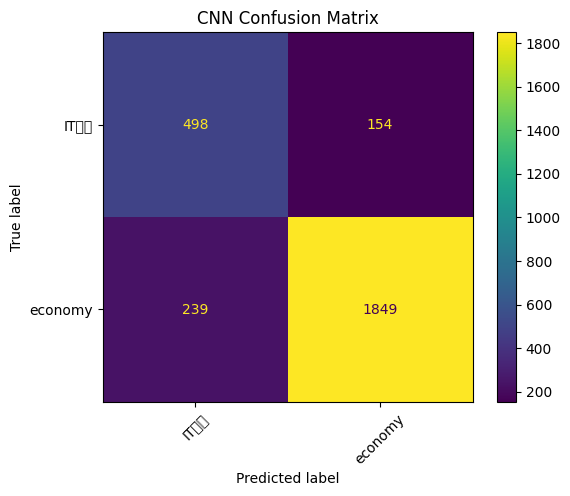

In [17]:
# ============================================================
# 17. Confusion Matrix 시각화
# ============================================================

cm = confusion_matrix(
    test_metrics["trues"],
    test_metrics["preds"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

plt.figure(figsize=(7, 6))
disp.plot(values_format="d")
plt.title(f"{MODEL_NAME} Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

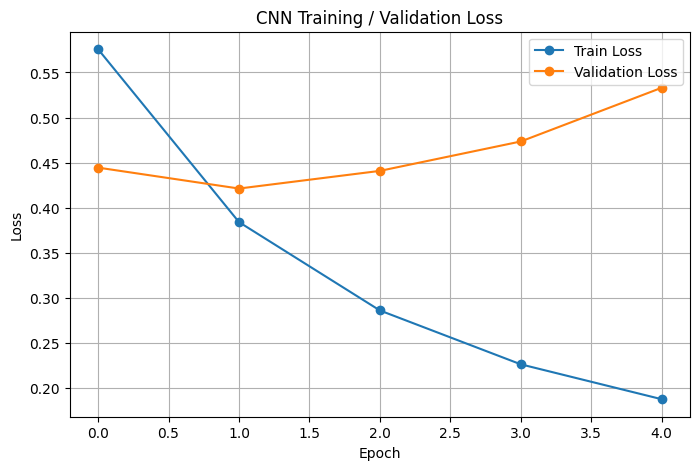

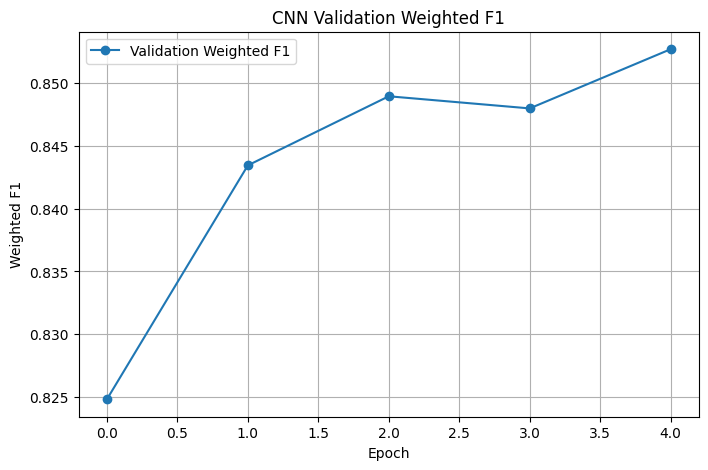

In [18]:
# ============================================================
# 18. Loss Curve / Validation F1 시각화
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], marker="o", label="Train Loss")
plt.plot(history["valid_loss"], marker="o", label="Validation Loss")
plt.title(f"{MODEL_NAME} Training / Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["valid_f1_weighted"], marker="o", label="Validation Weighted F1")
plt.title(f"{MODEL_NAME} Validation Weighted F1")
plt.xlabel("Epoch")
plt.ylabel("Weighted F1")
plt.legend()
plt.grid(True)
plt.show()

c:\miniconda\envs\edu_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\miniconda\envs\edu_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


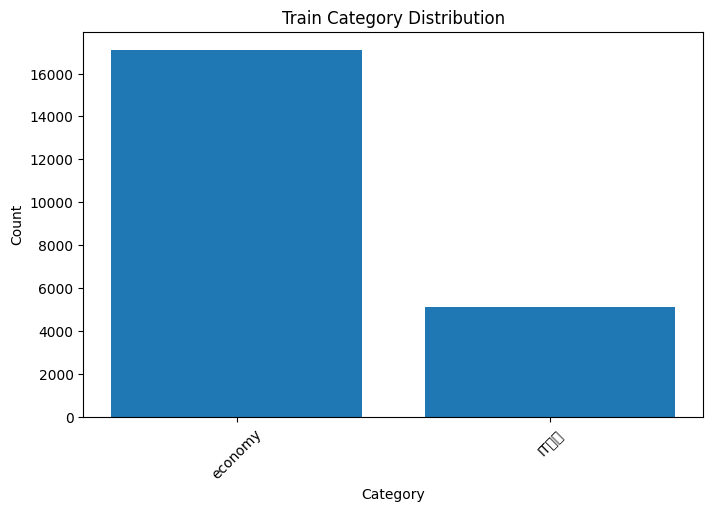

In [19]:
# ============================================================
# 19. 카테고리 분포 시각화
# ============================================================

category_counts = train_df[LABEL_COLUMN].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(category_counts.index, category_counts.values)
plt.title("Train Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [20]:
# ============================================================
# 20. 추론 함수
# ============================================================

def predict_news(text, model=None):
    """
    새로운 뉴스 문장이 들어왔을 때 카테고리를 예측하는 함수.

    model=None이면 현재 전역 model을 사용한다.
    이렇게 만들면 모델을 CNN에서 LSTM으로 바꿔도 같은 추론 함수를 쓸 수 있다.
    """
    if model is None:
        model_to_use = globals()["model"]
    else:
        model_to_use = model

    model_to_use.eval()

    cleaned = clean_text(text)
    tokens = tokenize(cleaned)
    sequence = tokens_to_sequence(tokens)

    tensor = torch.tensor(
        [sequence],
        dtype=torch.long
    ).to(DEVICE)

    with torch.no_grad():
        output = model_to_use(tensor)

        probs = torch.softmax(output, dim=1)

        pred_idx = torch.argmax(probs, dim=1).item()

    pred_category = label_encoder.inverse_transform([pred_idx])[0]
    pred_prob = probs[0][pred_idx].item()

    return pred_category, pred_prob


sample_texts = [
    "삼성전자 AI 반도체 투자 확대와 신제품 출시",
    "한국은행 기준금리 동결 이후 환율과 물가 전망",
    "신규 우주 관측 장비 개발로 과학 연구 성과 확대"
]

for text in sample_texts:
    category, prob = predict_news(text)

    print(f"문장: {text}")
    print(f"예측 카테고리: {category} / 확률: {prob:.4f}")
    print("-" * 60)

문장: 삼성전자 AI 반도체 투자 확대와 신제품 출시
예측 카테고리: IT과학 / 확률: 0.9774
------------------------------------------------------------
문장: 한국은행 기준금리 동결 이후 환율과 물가 전망
예측 카테고리: economy / 확률: 0.9997
------------------------------------------------------------
문장: 신규 우주 관측 장비 개발로 과학 연구 성과 확대
예측 카테고리: IT과학 / 확률: 0.9999
------------------------------------------------------------


In [21]:
# ============================================================
# 21. 모델 저장용 부가 파일 저장
# ============================================================

# 추론을 나중에 다시 하려면 모델뿐만 아니라 word_index, label_encoder도 필요하다.
with open(f"word_index_{MODEL_NAME.lower()}.pkl", "wb") as f:
    pickle.dump(word_index, f)

with open(f"label_encoder_{MODEL_NAME.lower()}.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("저장 완료:")
print(f"- {best_model_path}")
print(f"- word_index_{MODEL_NAME.lower()}.pkl")
print(f"- label_encoder_{MODEL_NAME.lower()}.pkl")

저장 완료:
- best_cnn_news.pt
- word_index_cnn.pkl
- label_encoder_cnn.pkl


## 22. CNN 핵심 정리

### CNN 설명 한 줄 요약

CNN은 문장 안에서 중요한 단어 조합 패턴을 빠르게 찾아 뉴스 카테고리를 분류하는 모델이다.

### CNN의 장점

- RNN/LSTM/GRU보다 병렬 처리가 쉬워 학습이 비교적 빠르다.
- 뉴스 제목/요약처럼 핵심 키워드가 뚜렷한 데이터에 잘 맞는다.
- `kernel_size`를 통해 2단어, 3단어, 4단어 묶음 같은 지역 패턴을 포착할 수 있다.

### CNN의 한계

- 문장의 긴 순서 흐름이나 장기 의존 관계를 이해하는 데는 RNN/LSTM/GRU보다 약할 수 있다.
- 단어 위치가 조금 달라져도 강한 패턴만 보는 경향이 있어 세밀한 문맥 이해는 Attention 계열 모델보다 부족할 수 있다.